<a href="https://colab.research.google.com/github/carlos1soler/data_analysis/blob/main/class_6_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<H1>Exercise Class 6 </H1>

<h2>Import the data and store it in a variable</h2>

In [ ]:
import pandas as pd
path = "https://www.ers.usda.gov/media/5628/vegetables-and-dry-pulses-trade-data.csv?v=74229"

In [ ]:
df = pd.read_csv(path)

In [ ]:
df

,Trade,GeographicDesc,Year,MonthNumber,MarketYear,Group,Subgroup,MarketSegment,CommodityName,CommodityDetail,UnitType,UnitDesc,Amount
0,Import,Albania,2025,11,2025/26,Dry pulses,Dried beans,Dried,White beans,Unspecified,Value,Thousand dollars,14.87600
1,Import,Albania,2025,11,2025/26,Dry pulses,Dried beans,Dried,White beans,Unspecified,Volume,Thousand pounds,14.25950
2,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Dark red,Value,Thousand dollars,54.05200
3,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Dark red,Volume,Thousand pounds,201.29086
4,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Unspecified,Value,Thousand dollars,48.00600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700388,Export,World,2017,1,2017,Vegetables,Vegetables,Juice,"Vegetables, other",Other,Volume,Thousand gallons,700.36462
700389,Export,World,2017,1,2017,Vegetables,Vegetables,Juice,"Vegetables, other",Other,Unit value,Dollars per gallon,5.57453
700390,Export,World,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,"Vegetables, other",Other,Value,Thousand dollars,12063.12400
700391,Export,World,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,"Vegetables, other",Other,Volume,Thousand pounds,17945.95663


<h2>Clean and filter the data: only keep rows that deal in Thousand dollars (we want a financial analysis), and only the rows specific to Imports. Remove countries that are marked as World</h2>

In [ ]:
df_analysis = df[
                    (df['UnitDesc'] == 'Thousand dollars') &
                    (df['Trade'] == 'Import') &
                    (df['GeographicDesc'] != 'World')
                ]

In [ ]:
df_analysis

,Trade,GeographicDesc,Year,MonthNumber,MarketYear,Group,Subgroup,MarketSegment,CommodityName,CommodityDetail,UnitType,UnitDesc,Amount
0,Import,Albania,2025,11,2025/26,Dry pulses,Dried beans,Dried,White beans,Unspecified,Value,Thousand dollars,14.876
2,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Dark red,Value,Thousand dollars,54.052
4,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Unspecified,Value,Thousand dollars,48.006
6,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Mung and urd beans,Unspecified,Value,Thousand dollars,135.155
8,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Navy beans,Navy or pea beans,Value,Thousand dollars,31.320
...,...,...,...,...,...,...,...,...,...,...,...,...,...
696632,Import,Vietnam,2017,1,2017,Vegetables,Vegetables,Juice,"Vegetables, other",Other,Value,Thousand dollars,7.560
696634,Import,Vietnam,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,"Vegetables, other",Other,Value,Thousand dollars,207.299
696636,Import,West Bank,2017,1,2017,Vegetables,Vegetables,Dried,"Vegetables, other",Other,Value,Thousand dollars,4.370
696638,Import,West Bank,2017,1,2017,Vegetables,Vegetables,Fresh,"Vegetables, other",Other,Value,Thousand dollars,42.136


<h2>Let's analyse the countries the US imports from. Create a bar graph that shows the number of countries we import from every year (hint: unique() returns the unique values as a list. nunique() returns the number of unique values). After that, display all the countries (as a list) that we imported from in 2024</h2>

<Axes: title={'center': 'Number of countries where US import from'}, xlabel='Year'>

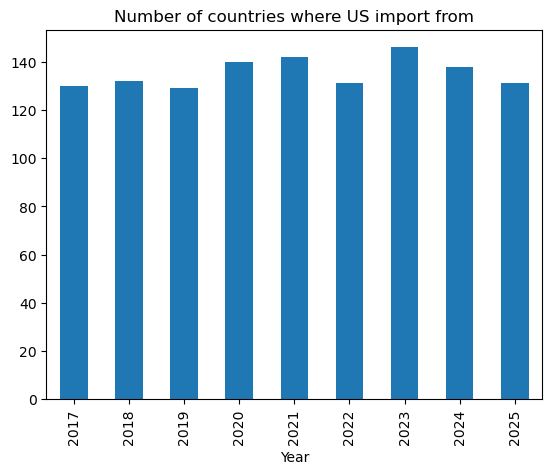

In [ ]:
df_analysis.groupby('Year')['GeographicDesc'].nunique().plot(kind = 'bar', title = 'Number of countries where US import from')

In [ ]:
countries2024 = df_analysis[df_analysis['Year'] == 2024]['GeographicDesc'].unique().tolist()
countries2024

['Afghanistan',
 'Albania',
 'Argentina',
 'Australia',
 'Belgium',
 'Brazil',
 'Cameroon',
 'Canada',
 'China',
 'Colombia',
 'Costa Rica',
 'Denmark',
 'Egypt',
 'El Salvador',
 'Ethiopia',
 'France',
 'Ghana',
 'Greece',
 'Guatemala',
 'Honduras',
 'Hong Kong',
 'Hungary',
 'India',
 'Israel',
 'Italy',
 'Jordan',
 'Kenya',
 'Lebanon',
 'Madagascar (Malagasy)',
 'Mexico',
 'Burma',
 'New Zealand',
 'Nicaragua',
 'Nigeria',
 'Paraguay',
 'Peru',
 'Poland',
 'Portugal',
 'South Africa',
 'Serbia',
 'South Korea',
 'Taiwan',
 'Tanzania',
 'Thailand',
 'Trinidad and Tobago',
 'Turkey',
 'Ukraine',
 'United Arab Emirates',
 'United Kingdom',
 'Vietnam',
 'Armenia',
 'Austria',
 'Azerbaijan',
 'Bangladesh',
 'Bolivia',
 'Bosnia-Hercegovina',
 'Bulgaria',
 'Cambodia',
 'Chile',
 'Croatia',
 'Czech Republic',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Fiji',
 'Germany',
 'Haiti',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Ivory Coast',
 'Jamaica',
 'Japan',
 'Kosovo',
 'Latvia',
 

<h2>Let's see what we spend the most on imports. Find out which commodity we spent the most on in 2025. And in 2024?</h2>

In [ ]:
mostImportedbyYear = (
    df_analysis[df_analysis["Year"].isin([2024, 2025])]
    .groupby(["Year", "CommodityName"])["Amount"]
    .sum()
    .reset_index(name="total")
    .sort_values(["Year","total"], ascending=[True, False])
    .groupby("Year")
    .head(1)
)
mostImportedbyYear

,Year,CommodityName,total
49,2024,Tomatoes,4536362.800
103,2025,Tomatoes,3411192.648


<h2>Which country did we import the most from in 2025, in dollar amount?  And in 2017?</h2>

In [ ]:
MostPopularCountryIn2025 = (
    df_analysis[df_analysis['Year'] == 2025]
    .groupby('GeographicDesc')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

MostPopularCountryIn2025

GeographicDesc
Mexico    8020697.502
Name: Amount, dtype: float64

In [ ]:
MostPopularCountryIn2017 = (
    df_analysis[df_analysis['Year'] == 2017]
    .groupby('GeographicDesc')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

MostPopularCountryIn2017

GeographicDesc
Mexico    6378527.199
Name: Amount, dtype: float64

<h2>Look back at our most imported commodity (answered above). Plot a line graph that shows the amount spent on imports of this commodity by year. What do you notice?</h2>

<Axes: title={'center': 'Imports of tomatoes by year'}, xlabel='Year'>

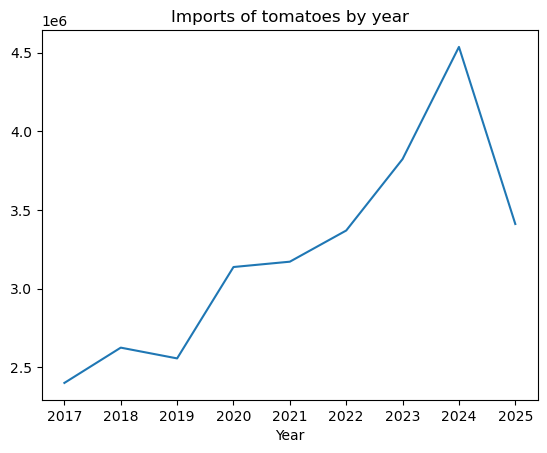

In [ ]:
tomatoes = (
    df_analysis[df_analysis['CommodityName'] == 'Tomatoes']
    .groupby('Year')['Amount']
    .sum()
)
tomatoes.plot(kind = 'line', title = 'Imports of tomatoes by year')

<h2>For this same commodity, take a look at the imports made by MonthNumber. Plot a bar graph to see how much was spent on imports every month of the year. Does this match what you could expect?</h2>

In [ ]:
tomatoesbymonth = (
    df_analysis[df_analysis['CommodityName'] == 'Tomatoes']
    .groupby(['Year', 'MonthNumber'])['Amount']
    .sum()
    .reset_index()
)

tomatoesbymonth['YearMonth'] = tomatoesbymonth['Year'].astype(str) + '-' + tomatoesbymonth['MonthNumber'].astype(str)
tomatoesbymonth


,Year,MonthNumber,Amount,YearMonth
0,2017,1,208536.710,2017-1
1,2017,2,188565.626,2017-2
2,2017,3,210790.675,2017-3
3,2017,4,196921.115,2017-4
4,2017,5,211359.621,2017-5
...,...,...,...,...
102,2025,7,283806.866,2025-7
103,2025,8,269910.958,2025-8
104,2025,9,282090.146,2025-9
105,2025,10,271135.641,2025-10


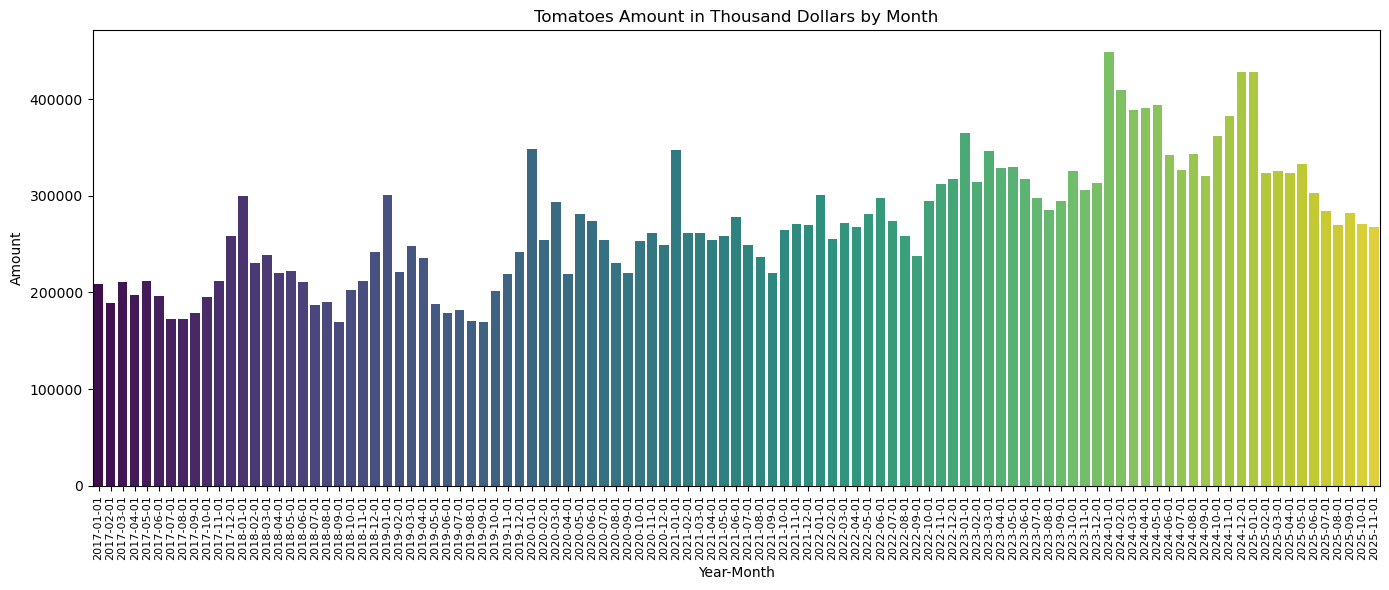

In [ ]:
import matplotlib.pyplot  as plt
import seaborn as sns

tomatoesbymonth['YearMonthDate'] = pd.to_datetime(
    tomatoesbymonth['YearMonth'] + '-01'  # add day to make a proper date
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=tomatoesbymonth,
    x="YearMonthDate",
    y="Amount",
    hue="YearMonthDate",        # assign x to hue
    palette="viridis",      # colors per x
    dodge=False,            # prevents separation of bars
    legend=False            # hide the duplicate legend
)

plt.xlabel("Year-Month")
plt.ylabel("Amount")
plt.title("Tomatoes Amount in Thousand Dollars by Month")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

<h2>We can see if monthly differences are due to lack of US supply or a price increase. Plot the same graph as above, but for Thousand pounds and not Thousand dollars (hint: you'll need to repeat some steps done above, specifically in the the cleaning and filtering section). Doing a visual analysis of the two bar graphs, does the US spend more on imports of the top commodity due to an increase in demand or an increase in price?</h2>

In [ ]:
df_analysis_pounds = df[
                    (df['UnitDesc'] == 'Thousand pounds') &
                    (df['Trade'] == 'Import') &
                    (df['GeographicDesc'] != 'World') &
                    (df['CommodityName'] == 'Tomatoes')
                ]
df_analysis_pounds

,Trade,GeographicDesc,Year,MonthNumber,MarketYear,Group,Subgroup,MarketSegment,CommodityName,CommodityDetail,UnitType,UnitDesc,Amount
418,Import,Armenia,2025,11,2025,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Paste,Volume,Thousand pounds,61.70959
420,Import,Armenia,2025,11,2025,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Sauce,Volume,Thousand pounds,13.05578
422,Import,Armenia,2025,11,2025,Vegetables,Vegetables,Dried,Tomatoes,Whole,Volume,Thousand pounds,3.08647
438,Import,Australia,2025,11,2025,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Paste,Volume,Thousand pounds,0.22046
440,Import,Australia,2025,11,2025,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Whole,Volume,Thousand pounds,211.56000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
696563,Import,Turkey,2017,1,2017,Vegetables,Vegetables,Dried,Tomatoes,Whole,Volume,Thousand pounds,779.94698
696565,Import,Turkey,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Whole,Volume,Thousand pounds,414.23095
696577,Import,Ukraine,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Ketchup,Volume,Thousand pounds,17.20708
696589,Import,United Arab Emirates,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,Tomatoes,Paste,Volume,Thousand pounds,37.32867


In [ ]:
df_analysis_pounds['YearMonth'] =  df_analysis_pounds['Year'].astype(str) + '-' + df_analysis_pounds['MonthNumber'].astype(str)

C:\Users\carlo\AppData\Local\Temp\ipykernel_4116\3886620383.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis_pounds['YearMonth'] =  df_analysis_pounds['Year'].astype(str) + '-' + df_analysis_pounds['MonthNumber'].astype(str)


In [ ]:
df_analysis_pounds_tomatoes =  (
    df_analysis_pounds[df_analysis_pounds['CommodityName'] == 'Tomatoes']
    .groupby(['YearMonth'])['Amount']
    .sum()
    .reset_index()
)
df_analysis_pounds_tomatoes

,YearMonth,Amount
0,2017-1,430551.10914
1,2017-10,346074.13924
2,2017-11,375684.58877
3,2017-12,395757.21697
4,2017-2,382637.51876
...,...,...
102,2025-5,490622.58034
103,2025-6,434708.78927
104,2025-7,417388.07683
105,2025-8,413469.21687


In [ ]:
df_analysis_pounds_tomatoes['YearMonthDate'] = pd.to_datetime(
    df_analysis_pounds_tomatoes['YearMonth'] + '-01'  # add day to make a proper date
)
df_analysis_pounds_tomatoes = df_analysis_pounds_tomatoes.sort_values(by='YearMonthDate')
df_analysis_pounds_tomatoes

,YearMonth,Amount,YearMonthDate
0,2017-1,430551.10914,2017-01-01
4,2017-2,382637.51876,2017-02-01
5,2017-3,446105.17153,2017-03-01
6,2017-4,400499.63578,2017-04-01
7,2017-5,406728.54795,2017-05-01
...,...,...,...
104,2025-7,417388.07683,2025-07-01
105,2025-8,413469.21687,2025-08-01
106,2025-9,418846.09965,2025-09-01
97,2025-10,421113.16823,2025-10-01


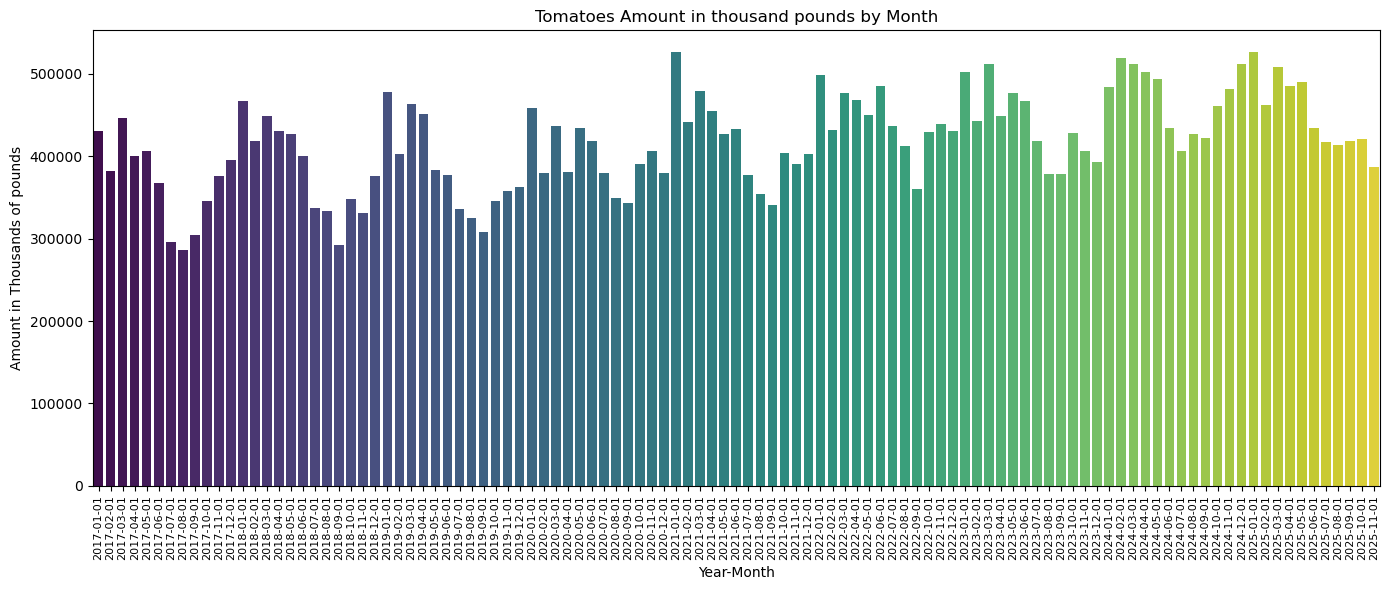

In [ ]:
plt.figure(figsize=(14,6))



sns.barplot(
    data=df_analysis_pounds_tomatoes,
    x="YearMonthDate",
    y="Amount",
    hue="YearMonthDate",        # assign x to hue
    palette="viridis",      # colors per x
    dodge=False,            # prevents separation of bars
    legend=False            # hide the duplicate legend
)

plt.xlabel("Year-Month")
plt.ylabel("Amount in Thousands of pounds")
plt.title("Tomatoes Amount in thousand pounds by Month")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
tomatoesbymonth = tomatoesbymonth.rename(columns={'Amount': 'Amount_Thousand_Dollars'})
tomatoesbymonth

,Year,MonthNumber,Amount_Thousand_Dollars,YearMonth,YearMonthDate
0,2017,1,208536.710,2017-1,2017-01-01
1,2017,2,188565.626,2017-2,2017-02-01
2,2017,3,210790.675,2017-3,2017-03-01
3,2017,4,196921.115,2017-4,2017-04-01
4,2017,5,211359.621,2017-5,2017-05-01
...,...,...,...,...,...
102,2025,7,283806.866,2025-7,2025-07-01
103,2025,8,269910.958,2025-8,2025-08-01
104,2025,9,282090.146,2025-9,2025-09-01
105,2025,10,271135.641,2025-10,2025-10-01


In [ ]:
df_analysis_pounds_tomatoes  = df_analysis_pounds_tomatoes.rename(columns={'Amount': 'Amount_Thousand_Pounds'})
df_analysis_pounds_tomatoes

,YearMonth,Amount_Thousand_Pounds,YearMonthDate
0,2017-1,430551.10914,2017-01-01
4,2017-2,382637.51876,2017-02-01
5,2017-3,446105.17153,2017-03-01
6,2017-4,400499.63578,2017-04-01
7,2017-5,406728.54795,2017-05-01
...,...,...,...
104,2025-7,417388.07683,2025-07-01
105,2025-8,413469.21687,2025-08-01
106,2025-9,418846.09965,2025-09-01
97,2025-10,421113.16823,2025-10-01


In [ ]:
Analysis_tomatoes = pd.merge(
    tomatoesbymonth,
    df_analysis_pounds_tomatoes[['YearMonth', 'Amount_Thousand_Pounds']],
    on='YearMonth',
    how='left'
)
Analysis_tomatoes

,Year,MonthNumber,Amount_Thousand_Dollars,YearMonth,YearMonthDate,Amount_Thousand_Pounds
0,2017,1,208536.710,2017-1,2017-01-01,430551.10914
1,2017,2,188565.626,2017-2,2017-02-01,382637.51876
2,2017,3,210790.675,2017-3,2017-03-01,446105.17153
3,2017,4,196921.115,2017-4,2017-04-01,400499.63578
4,2017,5,211359.621,2017-5,2017-05-01,406728.54795
...,...,...,...,...,...,...
102,2025,7,283806.866,2025-7,2025-07-01,417388.07683
103,2025,8,269910.958,2025-8,2025-08-01,413469.21687
104,2025,9,282090.146,2025-9,2025-09-01,418846.09965
105,2025,10,271135.641,2025-10,2025-10-01,421113.16823


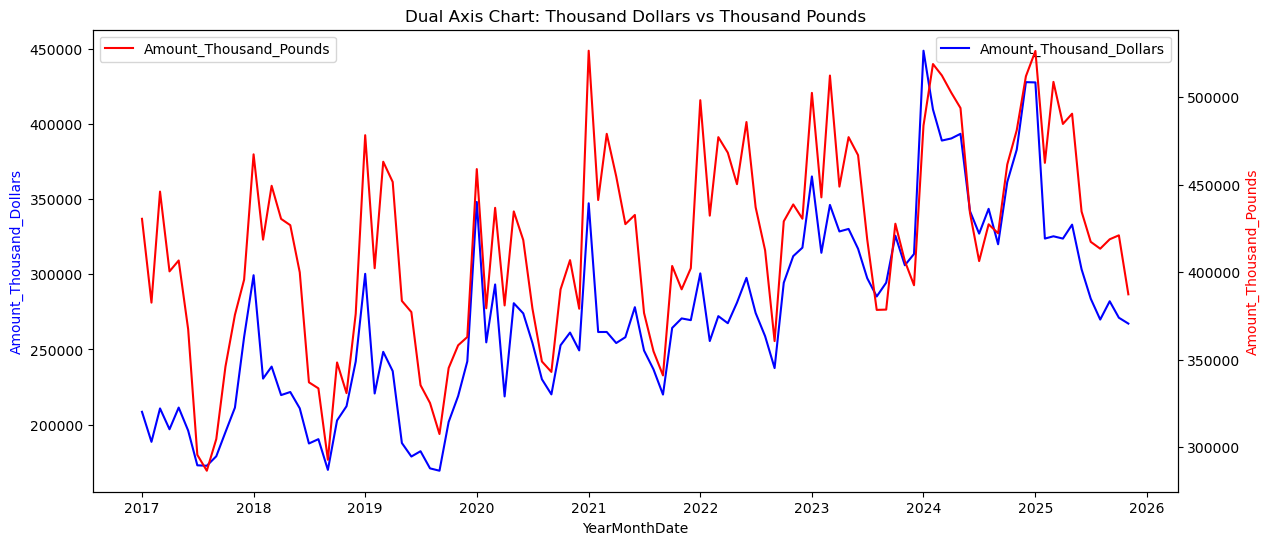

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=Analysis_tomatoes, x='YearMonthDate', y='Amount_Thousand_Dollars', ax=ax1, color='blue', label='Amount_Thousand_Dollars')
ax1.set_ylabel('Amount_Thousand_Dollars', color='blue')

ax2 = ax1.twinx()

sns.lineplot(data=Analysis_tomatoes, x='YearMonthDate', y='Amount_Thousand_Pounds', ax=ax2, color='red', label='Amount_Thousand_Pounds')
ax2.set_ylabel('Amount_Thousand_Pounds', color='red')

plt.title('Dual Axis Chart: Thousand Dollars vs Thousand Pounds')
plt.show()

<h3>The graph reveals that tomato imports follow a clear seasonal pattern. Demand typically peaks during the winter months from December through March,  while imports drop off during the summer and early fall. Notably, while import volumes have remained relatively stable over the years, costs have risen significantly. Comparing 2018 to 2025, it is clear that we are now spending much more money to import roughly the same amount of tomatoes, indicating a sharp rise in unit costs.</h3>